To begin copy this notebook to your own drive:

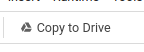


### Submission Instructions:
1. **Download the notebook** (in the menubar, select File$\rightarrow$Download .ipynb)
2. **Upload the downloaded notebook (.ipynb file) to your repository**.


Make sure you fill in any place that says `YOUR CODE HERE`, and all the cells include their outputs

Note: To use a GPU, do the following: Runtime$\rightarrow$Change runtime type$\rightarrow$ GPU

In [24]:
!pip install datasets
!pip install transformers
!pip install nltk
!pip install evaluate
%pip install accelerate
%pip install matplotlib


Looking in indexes: https://pypi.apple.com/simple
Looking in indexes: https://pypi.apple.com/simple
Looking in indexes: https://pypi.apple.com/simple
Looking in indexes: https://pypi.apple.com/simple
Looking in indexes: https://pypi.apple.com/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.apple.com/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 795.1 kB/s  0:00:10m0:00:0100:01
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 790.9 kB/s  0:00:03 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 854.9 kB/s  0:00:05 eta 0:00:01
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import nltk
nltk.download('punkt_tab')
## If you're usig older version of nltk, you night need to use this lin instead:
# nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/galbarak/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
# The assignment zip includes 2 files you need to use:
# 'glove.npy' and 'vocab.json'.
# you can upload the directly to this session storage, using the "files" button on the left menu,
# and then the "upload" button on the top of the sidebar. This upload is only valid for each session,
# so if you restart the session you'll neeed to upload the files again

# If you prefer, You can download the files directly to the sessio using these three lines:
# import gdown
# gdown.download('https://drive.google.com/uc?export=download&id=1PFOG06NEsTL6VieKQjMk1oNzyzcUtiWn', 'glove.npy', quiet=False)
# gdown.download('https://drive.google.com/uc?export=download&id=1-3SxpirQjmX-RCRyRjKdP2L7G_tNgp00', 'vocab.json', quiet=False)

In [4]:
import numpy as np
from datasets import load_dataset

raw_datasets = load_dataset("imdb")

/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from nltk.tokenize import word_tokenize
import json

with open("vocab.json") as f:
  vocab = json.load(f)

def tokenize_function(example):
  sentences = [x.lower() for x in example['text']]
  tokenized_sentences = [word_tokenize(x) for x in sentences]
  tokenized_idx = [[vocab[word] if word in vocab else vocab["unk"] for word in x] for x in tokenized_sentences]
  max_size = max([len(x) for x in tokenized_idx])
  final_tokenized_idx = tokenized_idx

  return {"labels":example['label'],'input_ids':final_tokenized_idx}

In [6]:
small_train_dataset = raw_datasets['train'].shuffle(seed=42).map(tokenize_function,batched=True)
small_eval_dataset = raw_datasets['test'].shuffle(seed=42).map(tokenize_function,batched=True)

In [7]:
def pad_sequence_to_length(
    sequence,
    desired_length: int,
    default_value = lambda: 0,
    padding_on_right: bool = True,
):
    sequence = list(sequence)
    # Truncates the sequence to the desired length.
    if padding_on_right:
        padded_sequence = sequence[:desired_length]
    else:
        padded_sequence = sequence[-desired_length:]
    # Continues to pad with default_value() until we reach the desired length.
    pad_length = desired_length - len(padded_sequence)
    # This just creates the default value once, so if it's a list, and if it gets mutated
    # later, it could cause subtle bugs. But the risk there is low, and this is much faster.
    values_to_pad = [default_value()] * pad_length
    if padding_on_right:
        padded_sequence = padded_sequence + values_to_pad
    else:
        padded_sequence = values_to_pad + padded_sequence
    return padded_sequence

In [8]:
from evaluate import load
metric = load("accuracy")

### If you're using older versions, use:
# metric = dataset.load_metric("accuracy")

def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [9]:
from dataclasses import dataclass

@dataclass
class DataCollatorWithPadding:

  def __call__(self, features):
    features_dict={}
    if "labels" in features[0]:

      features_dict["labels"] = torch.tensor([x.pop("labels") for x in features]).long()

    input_ids = [x.pop("input_ids") for x in features]
    max_len = max(len(x) for x in input_ids)
    masks = [[1]*len(x) for x in input_ids]

    features_dict["input_ids"] = torch.tensor([pad_sequence_to_length(x,max_len) for x in input_ids]).long()
    features_dict["attention_masks"] = torch.tensor([pad_sequence_to_length(x,max_len) for x in masks]).long()

    return features_dict


## SECTION A - DAN implentation

In [10]:
from torch import nn
import torch
#Use nn.Sequential and nn.Linear for the network, and nn.CrossEntropyLoss for the loss.
#Make sure that the final layer has output dimension of size 2.
class DAN(nn.Module):
  def __init__(self): # YOU ARE ALSO ALLOWED TO ADD PARAMETER TO THE __INIT__
          super().__init__()
          self.num_labels = 2
          self.embeddings = nn.Embedding.from_pretrained(torch.FloatTensor(np.load("glove.npy")))
          # YOUR CODE HERE
          embed_dim = self.embeddings.embedding_dim
          hidden_dim = 300
          self.classifier = nn.Sequential(
              nn.Linear(embed_dim, hidden_dim),
              nn.ReLU(),
              nn.Linear(hidden_dim, hidden_dim),
              nn.ReLU(),
              nn.Linear(hidden_dim, self.num_labels),
          )
          self.loss = nn.CrossEntropyLoss()
          # END YOUR END



  def forward(self,input_ids,attention_masks,labels=None,**kwargs):
      # YOUR CODE HERE
      embedded = self.embeddings(input_ids)
      mask = attention_masks.unsqueeze(-1).float()
      avg = (embedded * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
      # END YOUR END
      res = self.classifier(avg)
      loss = self.loss(res,labels)
      return {"loss":loss,"logits":res}


In [11]:
#Hint: You may want to look at https://huggingface.co/transformers/main_classes/callback.html
from transformers import Trainer
from transformers import TrainingArguments
from transformers import TrainerCallback


class AccuracyHistory(TrainerCallback):
    def __init__(self):
        self.epoch_acc = []

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics and "eval_accuracy" in metrics:
            self.epoch_acc.append(metrics["eval_accuracy"])


co = DataCollatorWithPadding()
training_args = TrainingArguments("DAN",
                                  # YOUR CODE HERE
                                  num_train_epochs= 30,  #must be at least 10.
                                  per_device_train_batch_size=100,
                                  per_device_eval_batch_size=100,
                                  learning_rate= 5e-3,
                                  # END YOUR END

                                  save_total_limit=2,
                                  log_level="error",
                                  eval_strategy="epoch") # Older version might need 'evaluation_strateg' instead
model = DAN()

history = AccuracyHistory()

trainer = Trainer(
    model=model,
    data_collator=co,
    args=training_args,
    callbacks = [
                 # YOUR CODE HERE
                 history,
                 # END YOUR END
    ],
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics,
)


In [12]:
trainer.train()

/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.405460,0.818800
2,0.444785,0.417405,0.806520
3,0.444785,0.404848,0.817360
4,0.393570,0.381968,0.832280
5,0.393570,0.445339,0.794440
6,0.381921,0.392921,0.825880
7,0.381921,0.393072,0.825720
8,0.376386,0.377246,0.832880
9,0.376386,0.391230,0.828520
10,0.368929,0.376135,0.833080


/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/galbarak/Desktop/NLP/.ven

TrainOutput(global_step=7500, training_loss=0.36066636149088543, metrics={'train_runtime': 416.9872, 'train_samples_per_second': 1798.617, 'train_steps_per_second': 17.986, 'total_flos': 0.0, 'train_loss': 0.36066636149088543, 'epoch': 30.0})

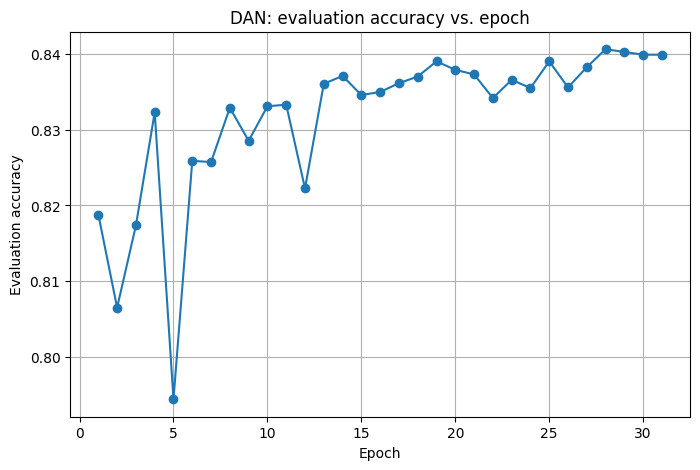

In [25]:
# You may add Cells & Code lines if you need
import matplotlib.pyplot as plt
epochs = range(1, len(history.epoch_acc) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, history.epoch_acc, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Evaluation accuracy")
plt.title("DAN: evaluation accuracy vs. epoch")
plt.grid(True)
plt.show()

## SECTION B - Trying drpout

In [26]:
from torch import nn
import torch
#Use nn.Sequential and nn.Linear for the network, and nn.CrossEntropyLoss for the loss.
#Make sure that the final layer has output dimension of size 2.
class DAN(nn.Module):
  def __init__(self, word_dropout=0.0):  # YOU ARE ALSO ALLOWED TO ADD PARAMETER TO THE __INIT__
          super().__init__()
          self.num_labels = 2
          self.embeddings = nn.Embedding.from_pretrained(torch.FloatTensor(np.load("glove.npy")))
          # YOUR CODE HERE
          self.word_dropout = word_dropout
          embed_dim = self.embeddings.embedding_dim
          hidden_dim = 300
          self.classifier = nn.Sequential(
              nn.Linear(embed_dim, hidden_dim),
              nn.ReLU(),
              nn.Linear(hidden_dim, hidden_dim),
              nn.ReLU(),
              nn.Linear(hidden_dim, self.num_labels),
          )
          self.loss = nn.CrossEntropyLoss()
          # END YOUR END



  def forward(self,input_ids,attention_masks,labels=None,**kwargs):
      # YOUR CODE HERE
      embedded = self.embeddings(input_ids)
      mask = attention_masks.float()
      if self.training and self.word_dropout > 0:
          keep = torch.bernoulli(torch.full_like(mask, 1 - self.word_dropout))
          mask = mask * keep
      mask = mask.unsqueeze(-1)
      avg = (embedded * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
      # END YOUR END
      res = self.classifier(avg)
      loss = self.loss(res,labels)
      return {"loss":loss,"logits":res}


{'eval_loss': '0.4204', 'eval_accuracy': '0.8069', 'eval_runtime': '6.507', 'eval_samples_per_second': '3842', 'eval_steps_per_second': '38.42', 'epoch': '1'}


/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.4432', 'grad_norm': '0.9677', 'learning_rate': '0.004335', 'epoch': '2'}


/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.3847', 'eval_accuracy': '0.8306', 'eval_runtime': '6.405', 'eval_samples_per_second': '3903', 'eval_steps_per_second': '39.03', 'epoch': '2'}


...

{'loss': '0.4252', 'grad_norm': '0.2602', 'learning_rate': '0.0003347', 'epoch': '14'}


/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.3756', 'eval_accuracy': '0.8378', 'eval_runtime': '6.382', 'eval_samples_per_second': '3917', 'eval_steps_per_second': '39.17', 'epoch': '14'}


/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.3767', 'eval_accuracy': '0.8374', 'eval_runtime': '6.443', 'eval_samples_per_second': '3880', 'eval_steps_per_second': '38.8', 'epoch': '15'}
{'train_runtime': '206', 'train_samples_per_second': '1820', 'train_steps_per_second': '18.2', 'train_loss': '0.4436', 'epoch': '15'}


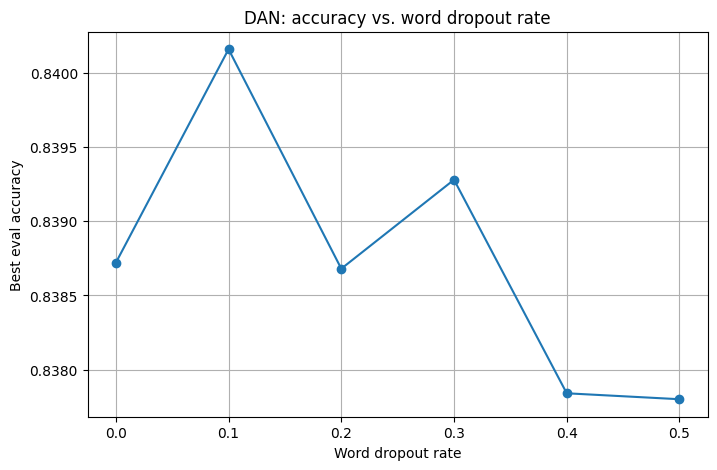

In [28]:
from transformers import Trainer
from transformers import TrainingArguments
from transformers import TrainerCallback
import matplotlib.pyplot as plt


class AccuracyHistory(TrainerCallback):
    def __init__(self):
        self.epoch_acc = []

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics and "eval_accuracy" in metrics:
            self.epoch_acc.append(metrics["eval_accuracy"])


co = DataCollatorWithPadding()

dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
acc_per_rate = {}
history_per_rate = {}

for rate in dropout_rates:
    training_args = TrainingArguments(f"DAN_dropout_{rate}",
                                      num_train_epochs=15,
                                      per_device_train_batch_size=100,
                                      per_device_eval_batch_size=100,
                                      learning_rate=5e-3,
                                      save_total_limit=2,
                                      log_level="error",
                                      eval_strategy="epoch")
    model = DAN(word_dropout=rate)
    history = AccuracyHistory()
    trainer = Trainer(
        model=model,
        data_collator=co,
        args=training_args,
        callbacks=[history],
        train_dataset=small_train_dataset,
        eval_dataset=small_eval_dataset,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    history_per_rate[rate] = history.epoch_acc
    acc_per_rate[rate] = max(history.epoch_acc)

# Plot best eval accuracy vs. dropout rate (Figure 2 in the DAN paper)
rates_sorted = sorted(acc_per_rate)
plt.figure(figsize=(8, 5))
plt.plot(rates_sorted, [acc_per_rate[r] for r in rates_sorted], marker="o")
plt.xlabel("Word dropout rate")
plt.ylabel("Best eval accuracy")
plt.title("DAN: accuracy vs. word dropout rate")
plt.grid(True)
plt.show()


## SCETION C - Different Layer num

In [15]:
# YOUR CODE HERE

## SECTION D - Activations

In [16]:
# YOUR CODE HERE

## SECRION E - Sample 5 examples

In [17]:
# YOUR CODE HERE